In [195]:
import networkx as nx
from metrics import nnd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def plot_on_axis(ts, struc_means, struc_devs, feat_means, feat_devs, nnd_val, ax):
    ax.fill_between(ts, struc_means, feat_means, color = "gray", alpha = 0.4)

    ax.errorbar(ts, struc_means, yerr=struc_devs, label="Structure", c = "black")
    ax.errorbar(ts, feat_means, yerr=feat_devs, label="Feature", c = "blue", linestyle = "dashed")

    nnrde_y_min = min(struc_means[-1], feat_means[-1])
    nnrde_y_max = max(struc_means[-1], feat_means[-1])
    final_gap = np.abs(struc_means[-1] - feat_means[-1])
    nnrd_y_adjusted = nnrde_y_min + 0.35*final_gap
    
    nnrd_root = min(np.min(np.array(struc_means) - np.array(struc_devs)), np.min(np.array(feat_means)-np.array(feat_devs)))

    ax.text(0.75, 0.7, f"$NNRD$:\n{nnd_val}", 
        bbox=dict(facecolor='white', edgecolor='green', boxstyle='round'))

    # if not default_xticks:
    # Format x-axis ticks
    t_ticks = np.linspace(0,1,6).tolist()
    ax.set_xticks(t_ticks)  # Ensure all unique noise levels are shown
    ax.set_xticklabels([f"{t:.1f}" for t in t_ticks])  # Format as two decimal places


    ax.set_xlim([ts[0]-0.025, ts[-1]+0.025])
    ax.set_yticks([])

    return ax

def plot_multi(res1, res2, res3):
    fig, axes = plt.subplots(ncols = 3, figsize = (7,2.5), sharey='all')

    for i, result_dict in enumerate([res1, res2, res3]):
        strucs = result_dict["structure"]
        feats = result_dict["feature"]
        ts = list(strucs.keys())

        # Ensure the x-axis values are numeric and sorted
        ts = sorted([float(t) for t in ts])  # Convert keys to floats and sort them

        struc_means = [np.mean([float(val) for val in strucs[str(t)]]) for t in ts]
        struc_devs = [np.std([float(val) for val in strucs[str(t)]]) for t in ts]
        feat_means = [np.mean([float(val) for val in feats[str(t)]]) for t in ts]
        feat_devs = [np.std([float(val) for val in feats[str(t)]]) for t in ts]
        nnd_val = np.around(nnd(result_dict), decimals = 3)
        ax = axes[i]
        ax = plot_on_axis(ts, struc_means, struc_devs, feat_means, feat_devs, nnd_val, ax)

    for ax in axes:
        ax.set_xlabel("Noise $N(t)$")

    axes[0].set_ylabel("Performance")
    axes[0].legend()

    axes[0].set_title("Both Used")
    axes[1].set_title("Graph-Less Learning")
    axes[2].set_title("Overfitting on Structure")
    plt.tight_layout()

    plt.show()



def plot_results(result_dict, extra_save_string="", return_path = False, default_xticks = False, return_ax = False):
    fig, ax = plt.subplots(figsize=(2.75, 2))
    dataset = result_dict["dataset"]
    task_type = result_dict["task_type"]

    ax.set_xlabel("Noise Level")
    perf_string = "Performance" #"RMSE" if task_type == "regression" else "ROC-AUC"
    ax.set_ylabel(perf_string)
    
    # ax.set_title(dataset)

    strucs = result_dict["structure"]
    feats = result_dict["feature"]
    ts = list(strucs.keys())

    # Ensure the x-axis values are numeric and sorted
    ts = sorted([float(t) for t in ts])  # Convert keys to floats and sort them

    struc_means = [np.mean([float(val) for val in strucs[str(t)]]) for t in ts]
    struc_devs = [np.std([float(val) for val in strucs[str(t)]]) for t in ts]
    feat_means = [np.mean([float(val) for val in feats[str(t)]]) for t in ts]
    feat_devs = [np.std([float(val) for val in feats[str(t)]]) for t in ts]
    nnd_val = np.around(nnd(result_dict), decimals = 3)

    ax = plot_on_axis(ts, struc_means, struc_devs, feat_means, feat_devs, nnd_val, ax)

    extra_string = "" if extra_save_string == "" else f"{extra_save_string}"
    # ax.legend()
    plt.tight_layout()

    if dataset not in os.listdir("figures/examples"):
        os.mkdir(f"figures/examples/{dataset}")

    plt.savefig(f"figures/examples/{dataset}/{extra_string}.png", dpi=600)
    plt.close()


    if return_path:
        return f"figures/analysis/{dataset}{extra_string}.png"


In [197]:
x = np.linspace(0,1,10)
stays_high = np.ones(x.shape[0]) * 0.8
descends = np.ones(x.shape[0])*0.8 - 0.3 * x

stays_high = {str(x[i]):[float(stays_high[i])] for i in range(stays_high.shape[0])}
descends = {str(x[i]):[float(descends[i])] for i in range(descends.shape[0])}

print(stays_high)

features_everything = {"dataset":"dummy",
                   "task_type":"classification",
                   "structure":stays_high,
                   "feature":descends}

plot_results(features_everything, extra_save_string="feature-forward", default_xticks=False)

{'0.0': [0.8], '0.1111111111111111': [0.8], '0.2222222222222222': [0.8], '0.3333333333333333': [0.8], '0.4444444444444444': [0.8], '0.5555555555555556': [0.8], '0.6666666666666666': [0.8], '0.7777777777777777': [0.8], '0.8888888888888888': [0.8], '1.0': [0.8]}


In [198]:
structure_everything = {"dataset":"dummy",
                   "task_type":"classification",
                   "structure":descends,
                   "feature":stays_high}

plot_results(structure_everything, extra_save_string="structure-forward", default_xticks=False)


In [199]:
always_low = np.ones(x.shape[0])*0.5
always_low[:1] = 1.
always_low = {str(x[i]):[float(always_low[i])] for i in range(always_low.shape[0])}

structure_catastrophe = {"dataset":"dummy",
                   "task_type":"classification",
                   "structure":stays_high,
                   "feature":always_low}

plot_results(structure_catastrophe, extra_save_string="feature-catastrophe", default_xticks=False)


In [200]:
from metrics import nnd
overfit_start = 0.7
overfit_feature = np.ones(x.shape[0]) * overfit_start - 0.2*x
overfit_structure = np.ones(x.shape[0]) * overfit_start + 0.1*x

overfit_feature = {str(x[i]):[float(overfit_feature[i])] for i in range(overfit_feature.shape[0])}
overfit_structure = {str(x[i]):[float(overfit_structure[i])] for i in range(overfit_structure.shape[0])}

structure_overfitting = {"dataset":"dummy",
                   "task_type":"classification",
                   "structure":overfit_structure,
                   "feature":overfit_feature}

plot_results(structure_overfitting, extra_save_string="structure-overfitting", default_xticks=False)

In [201]:
# from metrics import nnd
# overfit_start = 0.7
# overfit_feature = np.ones(x.shape[0])
# overfit_structure = np.ones(x.shape[0])

# overfit_feature = {str(x[i]):[float(overfit_feature[i])] for i in range(overfit_feature.shape[0])}
# overfit_structure = {str(x[i]):[float(overfit_structure[i])] for i in range(overfit_structure.shape[0])}

# structure_overfitting = {"dataset":"dummy",
#                    "task_type":"classification",
#                    "structure":overfit_structure,
#                    "feature":overfit_feature}

# plot_results(structure_overfitting, extra_save_string="perfect", default_xticks=False)

In [202]:
from metrics import nnd
overfit_start = 0.8
overfit_feature = np.ones(x.shape[0]) * overfit_start - 0.3*x
overfit_structure = np.ones(x.shape[0]) * overfit_start - 0.2*x

overfit_feature = {str(x[i]):[float(overfit_feature[i])] for i in range(overfit_feature.shape[0])}
overfit_structure = {str(x[i]):[float(overfit_structure[i])] for i in range(overfit_structure.shape[0])}

balanced = {"dataset":"dummy",
                   "task_type":"classification",
                   "structure":overfit_structure,
                   "feature":overfit_feature}

plot_results(structure_overfitting, extra_save_string="fairly-balanced", default_xticks=False)

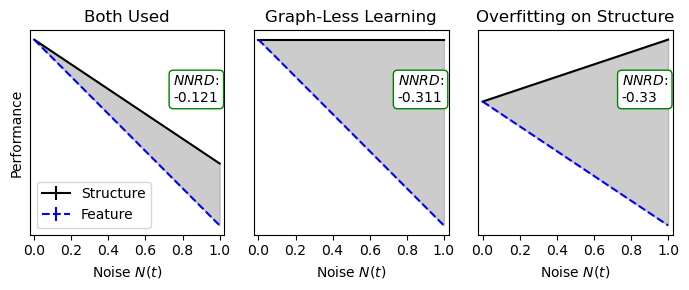

In [203]:
plot_multi(balanced, features_everything, structure_overfitting)